<a href="https://colab.research.google.com/github/emrizky1/machine-learning/blob/main/JS04/JS04_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
dataset = pd.read_csv('insurance.csv')
dataset.head()
print("Data Shape:", dataset.shape)
dataset.info()
print(dataset.describe())

Data Shape: (1338, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
               age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.296250     0.000000   4740.287150
50%      39.000000    30.400000     1.000000   9382.033000
75%      51.000000    34.693750     2.000000 

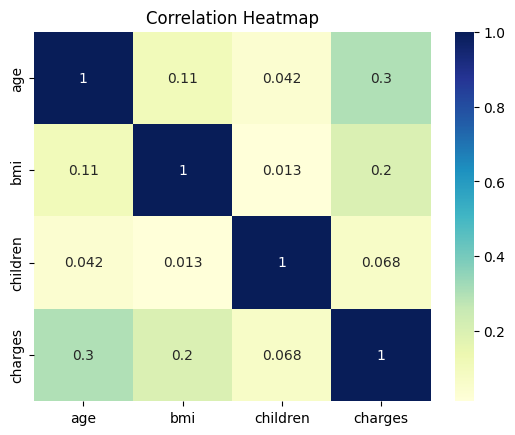

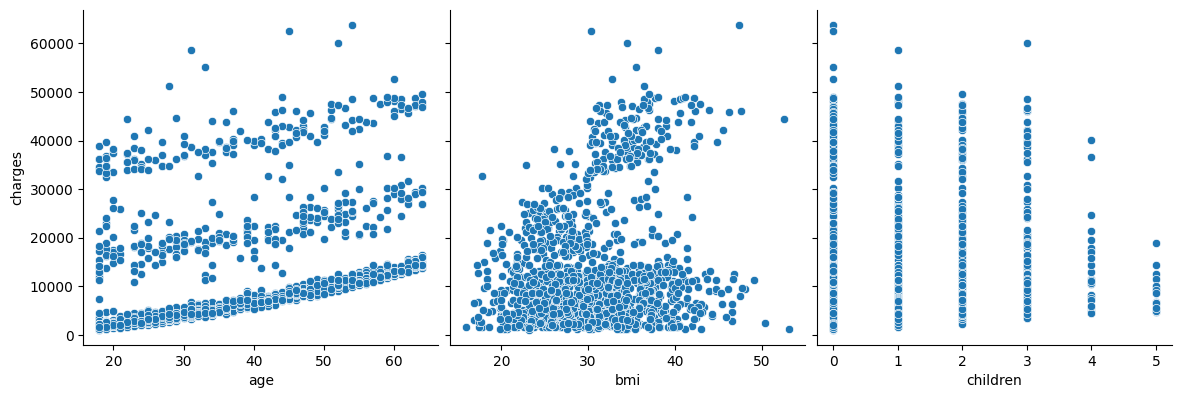

In [3]:
sns.heatmap(dataset.corr(numeric_only=True), cmap="YlGnBu", annot=True)
plt.title("Correlation Heatmap")
plt.show()

sns.pairplot(dataset, x_vars=['age', 'bmi', 'children'], y_vars='charges', height=4, aspect=1, kind='scatter')
plt.show()

In [4]:
dataset_encoded = pd.get_dummies(dataset, drop_first=True, dtype=int)
X = dataset_encoded.drop('charges', axis=1).values
y = dataset_encoded['charges'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=100)

In [5]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [6]:
sc_X = StandardScaler()
sc_y = StandardScaler()

X_train_scaled = sc_X.fit_transform(X_train)
X_test_scaled = sc_X.transform(X_test)

y_train_scaled = sc_y.fit_transform(y_train.reshape(-1, 1))

regressor = SVR(kernel='rbf')
regressor.fit(X_train_scaled, y_train_scaled.ravel())

y_pred_svr_scaled = regressor.predict(X_test_scaled)
y_pred_svr = sc_y.inverse_transform(y_pred_svr_scaled.reshape(-1, 1)).ravel()

In [7]:
def evaluate_model(y_actual, y_pred, model_name):
  mae = mean_absolute_error(y_actual, y_pred)
  mse = mean_squared_error(y_actual, y_pred)
  rmse = np.sqrt(mse)
  r2 = r2_score(y_actual, y_pred)

  print(f"=== {model_name} Evaluation ===")
  print("MAE:", mae)
  print("MSE:", mse)
  print("RMSE:", rmse)
  print("R-squared:", r2)
  print()

  evaluate_model(y_test, y_pred_lr, "Multiple Linear Regression")
  evaluate_model(y_test, y_pred_svr, "Support Vector Regression (RBF Kernel)")

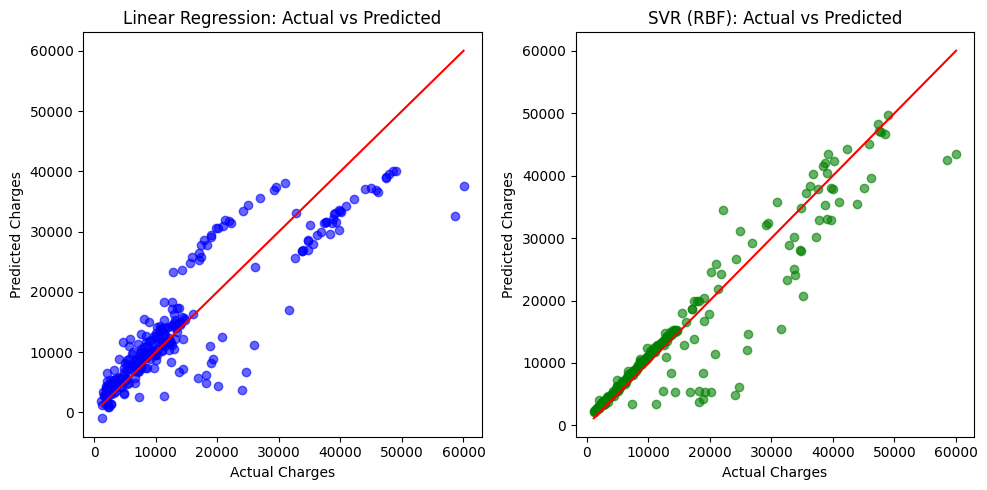

In [8]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred_lr, color='blue', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r')
plt.title('Linear Regression: Actual vs Predicted')
plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges')

plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred_svr, color='green', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r')
plt.title('SVR (RBF): Actual vs Predicted')
plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges')

plt.tight_layout()
plt.show()